In [9]:
import os
# This MUST be set before any other imports
os.environ["PYTENSOR_FLAGS"] = "optimizer_excluding=inplace"

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
from celerite2.pymc import GaussianProcess, terms

# 1. Generate Mock Data
np.random.seed(42)
t_opt = np.sort(np.random.uniform(0, 100, 50))
t_nir = np.sort(np.random.uniform(0, 100, 30))

# True parameters
true_period = 75.0
true_Q0 = 10.0
true_f = 0.5

# Simulate signal
def get_signal(t, sigma):
    omega = 2 * np.pi / true_period
    return sigma * np.exp(-t/200) * np.cos(omega * t)

y_opt = get_signal(t_opt, 1.0) + 0.1 * np.random.randn(len(t_opt))
y_nir = get_signal(t_nir, 0.5) + 0.1 * np.random.randn(len(t_nir))
diag_opt = np.ones_like(t_opt) * 0.1**2
diag_nir = np.ones_like(t_nir) * 0.1**2


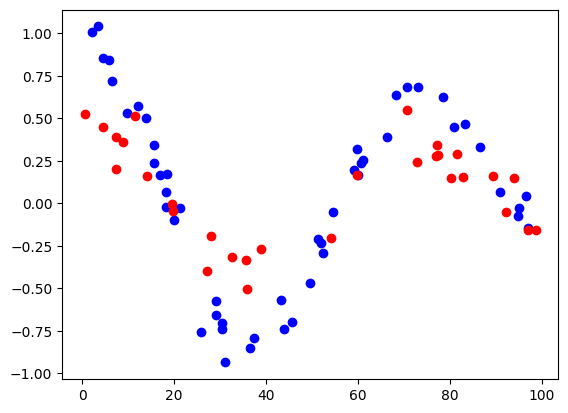

In [10]:
plt.scatter(t_opt, y_opt, label="Optical", color='blue')
plt.scatter(t_nir, y_nir, label="NIR", color='red')

In [11]:
# 2. Build the Model
with pm.Model() as model:
    # Shared parameters
    gp_period = pm.Uniform("gp_period", lower=50.0, upper=100.0)
    log_Q0 = pm.Uniform("log_Q0", lower=1, upper=8)
    log_dQ = pm.Uniform("log_dQ", lower=-3, upper=10)
    f = pm.Uniform("f", lower=0.1, upper=1.0)
    
    # Pre-calculate shared nodes (The "Clean Graph" trick)
    Q0_val = pm.Deterministic("Q0_val", pt.exp(log_Q0))
    dQ_val = pm.Deterministic("dQ_val", pt.exp(log_dQ))

    # Band-specific amplitudes
    sigma_gp = pm.HalfNormal("sigma_gp", sigma=[1.0,2.0], shape=2)

    # Define kernels using shared parameters
    kernel_opt = terms.RotationTerm(
        sigma=sigma_gp[0], period=gp_period, Q0=Q0_val, dQ=dQ_val, f=f
    )
    kernel_nir = terms.RotationTerm(
        sigma=sigma_gp[1], period=gp_period, Q0=Q0_val, dQ=dQ_val, f=f
    )
    kernel_ = terms.RotationTerm(
        sigma=sigma_gp[1], period=gp_period, Q0=Q0_val, dQ=dQ_val, f=f
    )

    # Define two GPs
    gp_opt = GaussianProcess(kernel_opt, t=t_opt, diag=diag_opt)
    gp_nir = GaussianProcess(kernel_nir, t=t_nir, diag=diag_nir)

    # Marginal Likelihoods
    gp_opt.marginal("obs_opt", observed=y_opt)
    gp_nir.marginal("obs_nir", observed=y_nir)

    # 3. Sample with safety flags
    # We use adapt_diag because adapt_full is unstable with shared GPs
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        init="jitter+adapt_diag",
        target_accept=0.9,
        random_seed=42
    )

print("Sampling successful!")

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:83: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:93: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:83: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:93: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [gp_period, log_Q0, log_dQ, f, sigma_gp]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling successful!


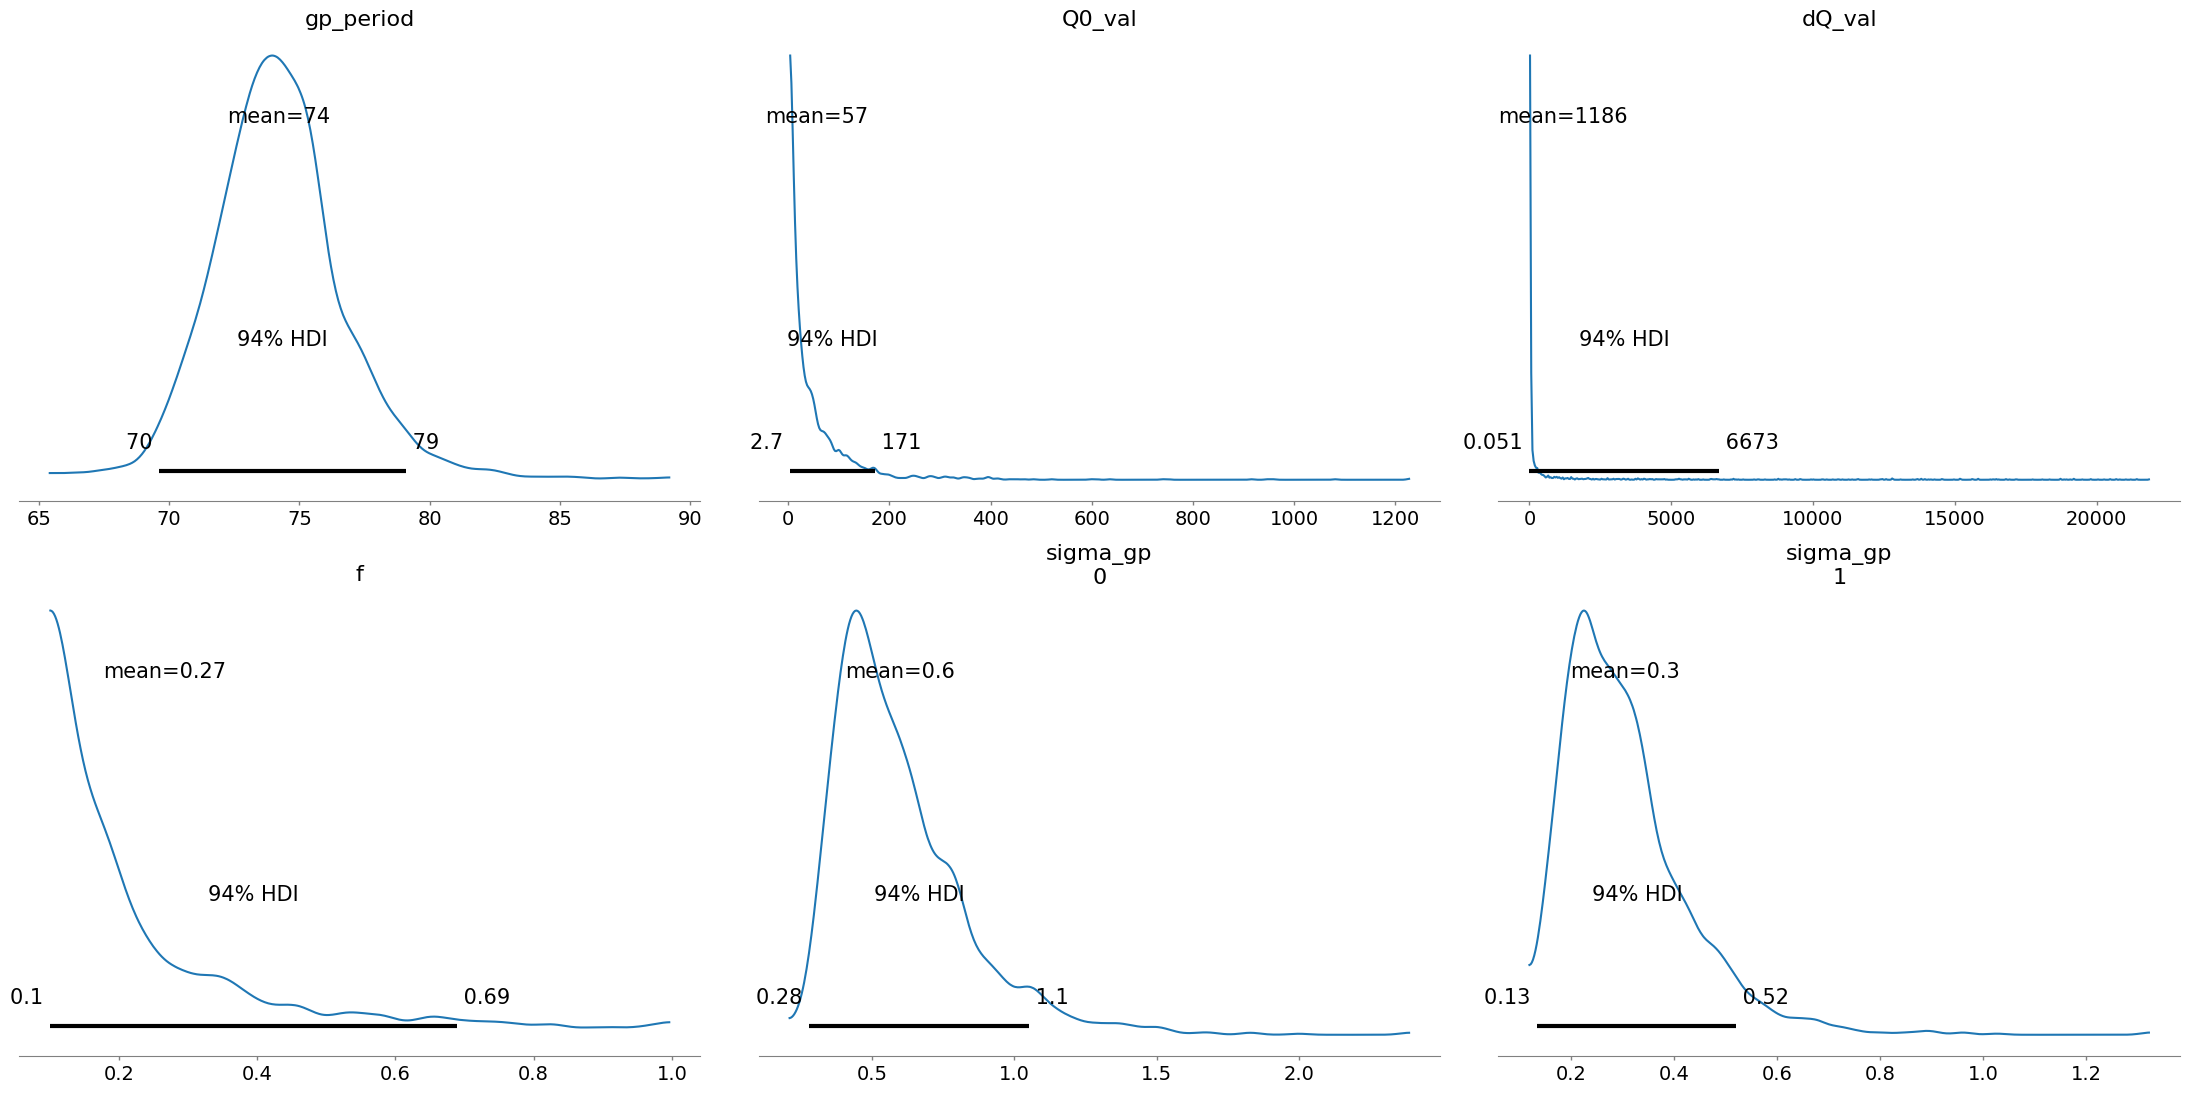

In [12]:
import arviz as az

# Posterior distributions
az.plot_posterior(trace, var_names=["gp_period", "Q0_val", "dQ_val", "f", "sigma_gp"])
plt.tight_layout()
plt.show()


In [13]:
# Prediction grid
t_grid = np.linspace(0, 100, 500)

with model:
    # Rebuild GPs with prediction grid
    gp_opt_pred = GaussianProcess(kernel_opt, t=t_opt, diag=diag_opt)
    gp_nir_pred = GaussianProcess(kernel_nir, t=t_nir, diag=diag_nir)

    mu_opt, var_opt = gp_opt_pred.predict(y_opt, t=t_grid, return_var=True)
    mu_nir, var_nir = gp_nir_pred.predict(y_nir, t=t_grid, return_var=True)

# Convert to numpy
mu_opt = mu_opt.eval()
std_opt = np.sqrt(var_opt.eval())

mu_nir = mu_nir.eval()
std_nir = np.sqrt(var_nir.eval())

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/blas.py:1736: FutureWarning: batched_dot is deprecated. Use `dot` in conjution with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


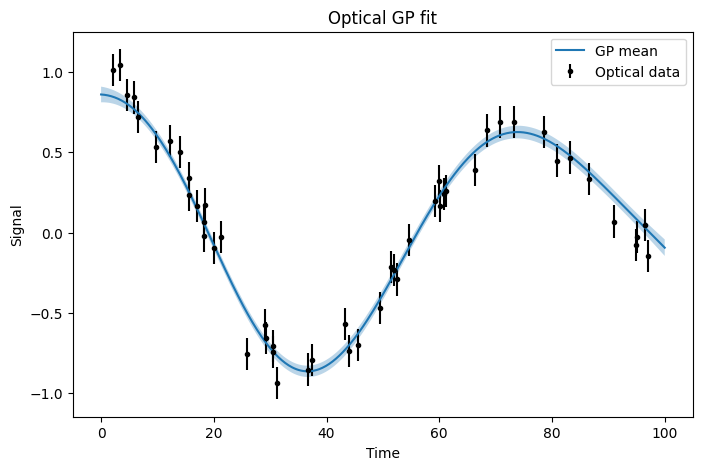

In [14]:
plt.figure(figsize=(8,5))
plt.errorbar(t_opt, y_opt, yerr=np.sqrt(diag_opt), fmt=".k", label="Optical data")
plt.plot(t_grid, mu_opt, label="GP mean")
plt.fill_between(t_grid, mu_opt-std_opt, mu_opt+std_opt, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Optical GP fit")
plt.legend()
plt.show()


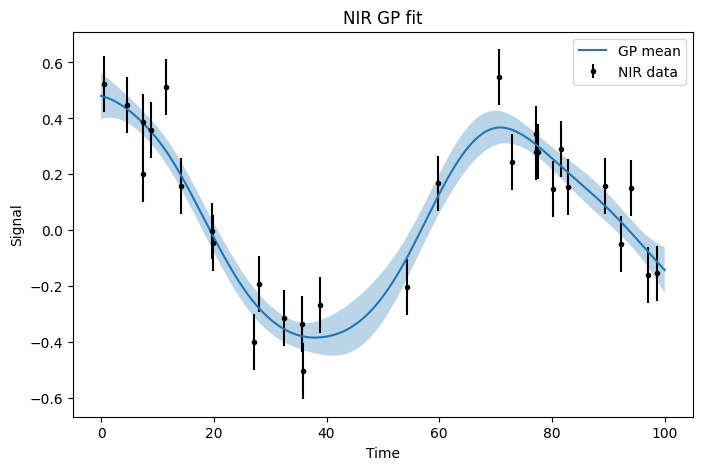

In [15]:
plt.figure(figsize=(8,5))
plt.errorbar(t_nir, y_nir, yerr=np.sqrt(diag_nir), fmt=".k", label="NIR data")
plt.plot(t_grid, mu_nir, label="GP mean")
plt.fill_between(t_grid, mu_nir-std_nir, mu_nir+std_nir, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("NIR GP fit")
plt.legend()
plt.show()
